# <i>Training Model</i>

### Load the data

In [10]:
import pandas as pd

df = pd.read_csv('cleaned_cardio.csv')
df.head()

,age,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,-0.417890,2,-0.997906,-0.133225,1,1,0,0,1,0,-1.044278
1,0.320819,1,0.797892,0.912060,3,1,0,0,1,1,1.420874
2,-0.270148,1,0.199293,-1.178511,3,1,0,0,0,1,-0.751234
3,-0.713373,2,1.396492,1.957346,1,1,0,0,1,1,0.238337
4,-0.861115,1,-1.596506,-2.223797,1,1,0,0,0,0,-0.845694


### Define Features & Target

In [11]:
X = df.drop('cardio', axis=1)
y = df['cardio']

### Train–Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


### 1. Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

### 2. Support Vactor Machine

In [14]:
from sklearn.svm import LinearSVC

svm = LinearSVC(max_iter=2000)
svm.fit(X_train, y_train)


LinearSVC(max_iter=2000)

### 3. K-Nearest Neighbors

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=7)

### Diff data for dicision tree and random forest

In [16]:
df2 = pd.read_csv('cleanedForTree_cardio.csv')
df2.head()

,age,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,50,2,110,80,1,1,0,0,1,0,21.967120
1,55,1,140,90,3,1,0,0,1,1,34.927679
2,51,1,130,70,3,1,0,0,0,1,23.507805
3,48,2,150,100,1,1,0,0,1,1,28.710479
4,47,1,100,60,1,1,0,0,0,0,23.011177


In [17]:
X2 = df2.drop('cardio', axis=1)
y2 = df2['cardio']

In [18]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.3,
    random_state=42
)

### 4. Decision Tree

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X2_train, y2_train)


DecisionTreeClassifier(max_depth=10, random_state=42)

### 5. Random forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf.fit(X2_train, y2_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

### one common evaluation function

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy :", accuracy_score(y_test, y_test_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


### Evaluate 1, 2, 3

In [22]:
models1 = {
    "Logistic Regression": lr,
    "SVM": svm,
    "KNN": knn
}

for name, model in models1.items():
    print("="*50)
    print(name)
    evaluate_model(model, X_train, X_test, y_train, y_test)


Logistic Regression
Train Accuracy: 0.7275110805917973
Test Accuracy : 0.7269990775355635

Confusion Matrix:
 [[8129 2197]
 [3426 6845]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.79      0.74     10326
           1       0.76      0.67      0.71     10271

    accuracy                           0.73     20597
   macro avg       0.73      0.73      0.73     20597
weighted avg       0.73      0.73      0.73     20597

SVM
Train Accuracy: 0.7263666063216597
Test Accuracy : 0.7267563237364665

Confusion Matrix:
 [[8214 2112]
 [3516 6755]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.74     10326
           1       0.76      0.66      0.71     10271

    accuracy                           0.73     20597
   macro avg       0.73      0.73      0.73     20597
weighted avg       0.73      0.73      0.73     20597

KNN
Train Accuracy: 0.7710843373493976

### Evaluate 4,5

In [23]:
models2 = {
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models2.items():
    print("="*50)
    print(name)
    evaluate_model(model, X2_train, X2_test, y2_train, y2_test)

Decision Tree
Train Accuracy: 0.7517531264956198
Test Accuracy : 0.7240374811865806

Confusion Matrix:
 [[8038 2288]
 [3396 6875]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.78      0.74     10326
           1       0.75      0.67      0.71     10271

    accuracy                           0.72     20597
   macro avg       0.73      0.72      0.72     20597
weighted avg       0.73      0.72      0.72     20597

Random Forest
Train Accuracy: 0.7545206733670433
Test Accuracy : 0.7333106763120842

Confusion Matrix:
 [[8148 2178]
 [3315 6956]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75     10326
           1       0.76      0.68      0.72     10271

    accuracy                           0.73     20597
   macro avg       0.74      0.73      0.73     20597
weighted avg       0.74      0.73      0.73     20597



### Comparision for All

In [24]:
import pandas as pd

results = []

for name, model in models1.items():
    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test Accuracy": accuracy_score(y_test, model.predict(X_test))
    })

for name, model in models2.items():
    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y2_train, model.predict(X2_train)),
        "Test Accuracy": accuracy_score(y2_test, model.predict(X2_test))
    })

pd.DataFrame(results)

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.727511,0.726999
1,SVM,0.726367,0.726756
2,KNN,0.771084,0.704569
3,Decision Tree,0.751753,0.724037
4,Random Forest,0.754521,0.733311


### Test Accuracy graf

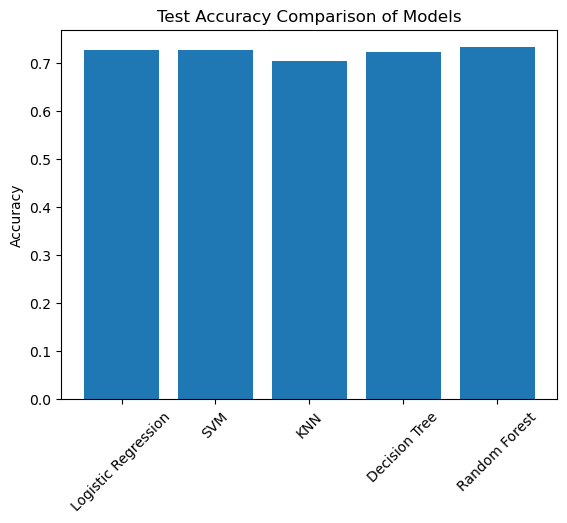

In [25]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "SVM", "KNN", "Decision Tree", "Random Forest"]
test_acc = [0.7269, 0.7267, 0.7045, 0.7240, 0.7333]

#plt.figure()
plt.bar(models, test_acc)
plt.xticks(rotation=45)
plt.title("Test Accuracy Comparison of Models")
plt.ylabel("Accuracy")
plt.show()


### Train vs Test Accuracy Graph

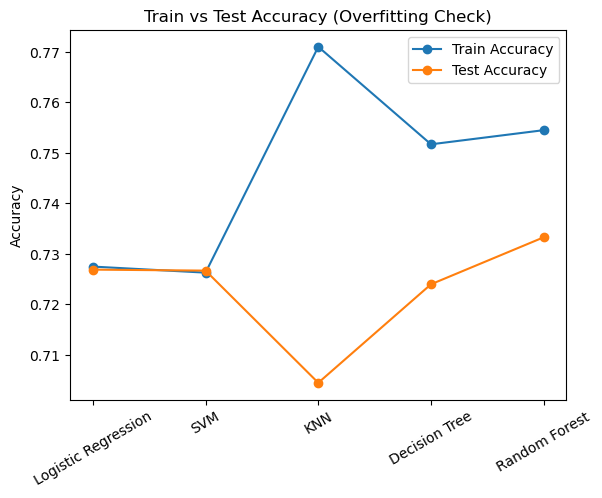

In [26]:
train_acc = [0.7275, 0.7263, 0.7710, 0.7517, 0.7545]

plt.figure()
plt.plot(models, train_acc, marker="o", label="Train Accuracy")
plt.plot(models, test_acc, marker="o", label="Test Accuracy")

plt.xticks(rotation=30)
plt.title("Train vs Test Accuracy (Overfitting Check)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### ROC curve for all

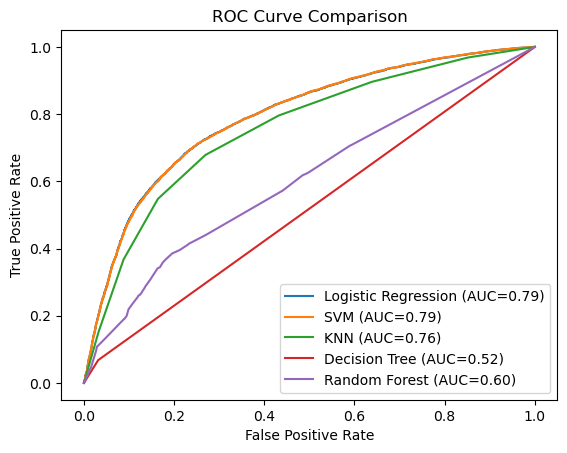

In [ ]:
from sklearn.metrics import roc_curve, auc

models_dict = {
    "Logistic Regression": lr,
    "SVM": svm,
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf
}

plt.figure()

for name, model in models_dict.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


### f1 score 

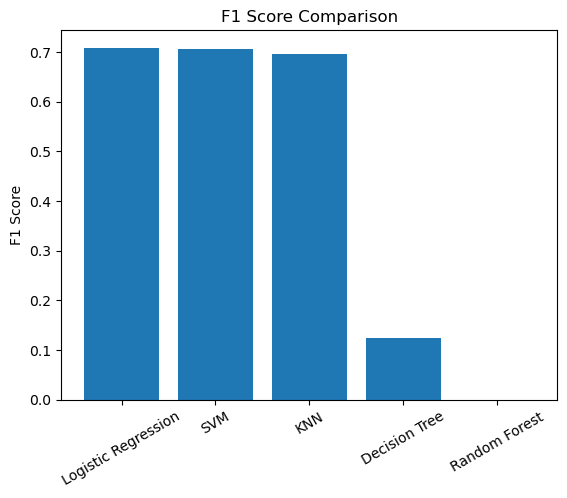

In [28]:
from sklearn.metrics import f1_score

f1_scores = []

for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    f1_scores.append(f1_score(y_test, y_pred))

plt.figure()
plt.bar(models_dict.keys(), f1_scores)
plt.xticks(rotation=30)
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()
